# Regresión polinomial

|                |                  |
:----------------|------------------|
| **Nombre**     | Omar Mendoza     |
| **Fecha**      | 24/08/2026       |
| **Expediente** | 757806           |

Regresiones de orden 1, 5 y 9 para los archivos bateria_tableta.txt y
Salarios_minimos.csv

## Batería de la tableta

In [1]:
# Leer archivo bateria_tableta.txt como csv

import pandas as pd

datos = pd.read_csv("bateria_tableta.txt")

print(datos)

    carga  duracion
0    2.81      5.62
1    7.14      8.00
2    2.72      5.44
3    3.87      7.74
4    1.90      3.80
..    ...       ...
95   4.38      8.00
96   8.06      8.00
97   8.05      8.00
98   1.10      2.20
99   6.65      8.00

[100 rows x 2 columns]


In [2]:
datos.shape # Renglones y columnas

(100, 2)

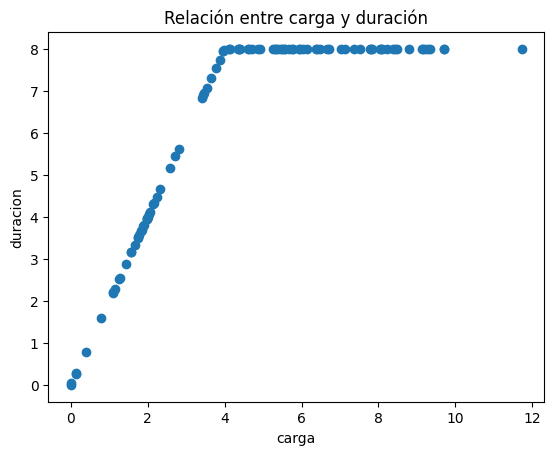

In [3]:
# Gráfica de los datos

import matplotlib.pyplot as plt

plt.scatter(datos['carga'], datos['duracion'])
plt.xlabel('carga')
plt.ylabel('duracion')
plt.title('Relación entre carga y duración')
plt.show()

In [4]:
import numpy as np

X_v = np.reshape(datos['carga'].values, (-1, 1))
y = datos['duracion'].values

In [5]:
# Matriz de X para cada orden agregando potencias de x
# Sin columna de unos porque sklearn ya pone el intercepto

X1 = X_v

X5 = np.hstack([X_v, X_v**2, X_v**3, X_v**4, X_v**5])

X9 = np.hstack([X_v, X_v**2, X_v**3, X_v**4, X_v**5,
                X_v**6, X_v**7, X_v**8, X_v**9])

In [6]:
from sklearn.linear_model import LinearRegression

lr1 = LinearRegression()
lr1.fit(X1, y)

lr5 = LinearRegression()
lr5.fit(X5, y)

lr9 = LinearRegression()
lr9.fit(X9, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [7]:
lr1.intercept_ # Intercepto, B0

np.float64(2.870541111621019)

In [8]:
lr1.coef_ # B1

array([0.72955585])

El modelo de orden 1 queda como 2.870541111621019 + 0.729555847010492x

In [9]:
lr5.coef_ # B1 a B5

array([ 8.35890085e-01,  1.10347381e+00, -3.23550360e-01,  3.20123836e-02,
       -1.07054199e-03])

In [10]:
lr9.coef_ # B1 a B9

array([ 2.37235338e+00, -2.15595582e-01, -4.37810578e-01,  5.06419554e-01,
       -2.05326541e-01,  4.07627631e-02, -4.30680375e-03,  2.33074964e-04,
       -5.08969063e-06])

In [11]:
# R2 de cada modelo

print("Orden 1:", lr1.score(X1, y))
print("Orden 5:", lr5.score(X5, y))
print("Orden 9:", lr9.score(X9, y))

Orden 1: 0.6872269726243967
Orden 5: 0.9953630126134433
Orden 9: 0.9989126729469291


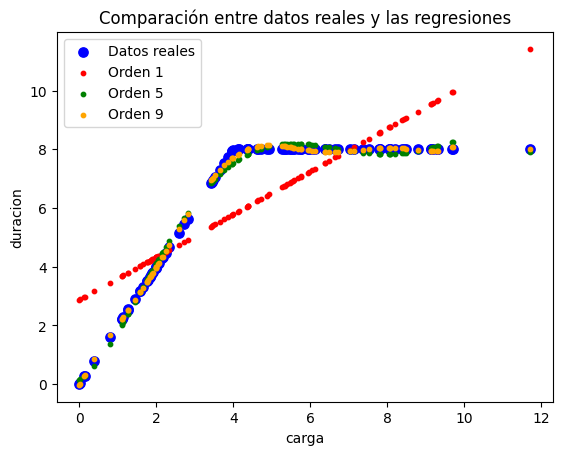

In [12]:
# Comparación entre los datos y las regresiones
# Los datos con punto más grande para que no los tapen los modelos

plt.scatter(X_v, y, s=45, color='blue', label='Datos reales')
plt.scatter(X_v, lr1.predict(X1), s=10, color='red', label='Orden 1')
plt.scatter(X_v, lr5.predict(X5), s=10, color='green', label='Orden 5')
plt.scatter(X_v, lr9.predict(X9), s=10, color='orange', label='Orden 9')
plt.xlabel('carga')
plt.ylabel('duracion')
plt.title('Comparación entre datos reales y las regresiones')
plt.legend()
plt.show()

Los datos no son recta. Suben y luego se quedan planos en 8 horas. El de orden 1
se queda corto y en las cargas altas pasa de 8 horas. Eso no puede pasar. Los de
orden 5 y 9 sí agarran el codo. El de orden 9 se ondula en la parte plana y
brinca al final donde nada más hay un dato con carga de 11.72

## Salarios mínimos

In [13]:
# Leer archivo Salarios_minimos.csv

datos2 = pd.read_csv("Salarios_minimos.csv")

print(datos2)

    Periodo  Salario
0   1988.25     8.00
1   1989.00     8.64
2   1989.50     9.16
3   1990.00    10.08
4   1990.84    11.90
5   1991.84    13.33
6   1993.00    14.27
7   1994.00    15.27
8   1995.00    16.34
9   1995.30    18.30
10  1996.00    20.15
11  1996.30    22.60
12  1997.00    26.45
13  1998.00    30.20
14  1999.00    34.45
15  2000.00    37.90
16  2001.00    40.35
17  2002.00    42.15
18  2003.00    43.65
19  2004.00    45.24
20  2005.00    46.80
21  2006.00    48.67
22  2007.00    50.57
23  2008.00    52.59
24  2009.00    54.80
25  2010.00    57.46
26  2011.00    59.82
27  2012.00    62.33
28  2013.00    64.76
29  2014.00    67.29
30  2015.00    70.10
31  2016.00    73.04
32  2017.00    80.04
33  2018.00    88.36


In [14]:
datos2.shape # Renglones y columnas

(34, 2)

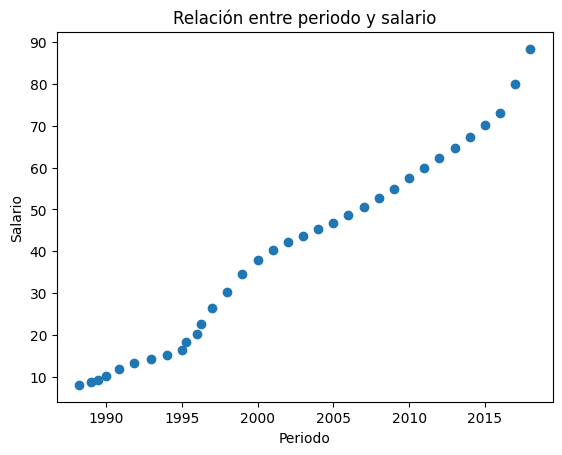

In [15]:
plt.scatter(datos2['Periodo'], datos2['Salario'])
plt.xlabel('Periodo')
plt.ylabel('Salario')
plt.title('Relación entre periodo y salario')
plt.show()

Al periodo hay que restarle 1988 antes de sacar las potencias. Si se deja el año
tal cual 2000 elevado a la novena da un número enorme y la regresión sale mal. El
orden 5 queda en 0.9857546631343813 y el orden 9 en 0.9857920242932819. Es casi
igual que la recta

In [16]:
X_v2 = np.reshape(datos2['Periodo'].values - 1988, (-1, 1))
y2 = datos2['Salario'].values

In [17]:
X1_2 = X_v2

X5_2 = np.hstack([X_v2, X_v2**2, X_v2**3, X_v2**4, X_v2**5])

X9_2 = np.hstack([X_v2, X_v2**2, X_v2**3, X_v2**4, X_v2**5,
                  X_v2**6, X_v2**7, X_v2**8, X_v2**9])

In [18]:
lr1_2 = LinearRegression()
lr1_2.fit(X1_2, y2)

lr5_2 = LinearRegression()
lr5_2.fit(X5_2, y2)

lr9_2 = LinearRegression()
lr9_2.fit(X9_2, y2)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [19]:
lr1_2.intercept_ # Intercepto, B0

np.float64(3.715577808507632)

In [20]:
lr1_2.coef_ # B1

array([2.52832885])

El modelo de orden 1 queda como 3.715577808507632 + 2.528328847811839x donde x es
el periodo menos 1988

In [21]:
lr5_2.coef_ # B1 a B5

array([-1.49686284e+00,  5.99556176e-01, -3.04530405e-02,  4.52192270e-04,
        1.59814416e-06])

In [22]:
lr9_2.coef_ # B1 a B9

array([-1.46624566e+00,  3.00577411e+00, -1.21866836e+00,  2.34496518e-01,
       -2.38873943e-02,  1.37769522e-03, -4.53109532e-05,  7.93065897e-07,
       -5.73465675e-09])

In [23]:
print("Orden 1:", lr1_2.score(X1_2, y2))
print("Orden 5:", lr5_2.score(X5_2, y2))
print("Orden 9:", lr9_2.score(X9_2, y2))

Orden 1: 0.9844566663095193
Orden 5: 0.996151801334014
Orden 9: 0.9994664125272349


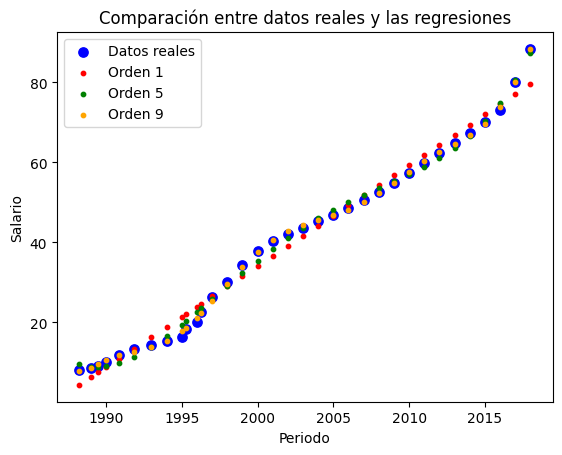

In [24]:
plt.scatter(datos2['Periodo'], y2, s=45, color='blue', label='Datos reales')
plt.scatter(datos2['Periodo'], lr1_2.predict(X1_2), s=10, color='red', label='Orden 1')
plt.scatter(datos2['Periodo'], lr5_2.predict(X5_2), s=10, color='green', label='Orden 5')
plt.scatter(datos2['Periodo'], lr9_2.predict(X9_2), s=10, color='orange', label='Orden 9')
plt.xlabel('Periodo')
plt.ylabel('Salario')
plt.title('Comparación entre datos reales y las regresiones')
plt.legend()
plt.show()

El salario sube cada vez más rápido y por eso la recta no le atina. Queda abajo
de los puntos al principio y al final y arriba en la parte de en medio. Los de
orden 5 y 9 siguen mejor la subida